# Cost-critic TD($\lambda$) — sweep `tuukeqwe`

**Standalone.** Nothing is imported from `plots/` or the other notebooks; data is pulled from
wandb once and cached, so re-runs are offline.

**Sweep** `liam-paull/calibration_rl/tuukeqwe` — CPO on `SafetyPointGoal1-v0`, sweeping
`lam_c`, the TD($\lambda$) trace used to build the **cost** critic's target:

| parameter | values |
|---|---|
| `lam-c` | 0, 0.3, 0.6, 0.9, 0.95, 1 |
| `algo-cfgs.update-iters` | 2, 5 |
| `model-cfgs.critic.lr` | 3e-4, 1e-4 |
| `seed` | 1 … 5 |

$\lambda_c = 0$ is a one-step TD target, $\lambda_c = 1$ the full Monte-Carlo return; the
values between trade the bias of bootstrapping against the variance of the return.

Each $\lambda_c$ is shown at **its own** best config: the 2x2 nuisance grid
(`update_iters` x `critic_lr`) is scored by `SELECT["criterion"]` *within* that
$\lambda_c$, so the curve for each trace is the best that trace can do.

### The five columns

1. **Return vs cost** — final performance, one standard-error ellipse per $\lambda_c$
2. **Pred vs target (train)** — Corr($\hat V_c$, TD($\lambda$) target) on the training batch
3. **Pred vs target (eval)** — the same correlation on the held-out eval probes
4. **Pred vs MC truth (eval)** — Corr($\hat V_c$, $\tilde V_c$), against the Monte-Carlo truth
5. **Estimation error (eval)** — $\hat V_c - \tilde V_c$; above zero the critic over-predicts

Columns 2 and 3 ask how well the critic hits *the target it was trained on*; column 4 asks
whether that target was the right thing to hit. The gap between them is what $\lambda_c$ buys.

### Layout

1. **Config** — paths, sweep, how each $\lambda_c$'s config is chosen
2. **Style** — `STYLE` and `TEXT`: every colour, size and string, in one place
3. **Utilities** — fetching, selection, drawing primitives
4. **Load**
5. **The figure**

To restyle everything, edit `STYLE`/`TEXT` in section 2 and re-run.

## 1. Config

In [1]:
import pathlib

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon

# Repo-anchored, so the same cache is used wherever the kernel starts.
REPO = pathlib.Path.cwd().resolve()
while not (REPO / "omnisafe").is_dir() and not (REPO / "plots").is_dir():
    if REPO.parent == REPO:
        raise RuntimeError("could not find the MICE repo root")
    REPO = REPO.parent

SWEEP = "liam-paull/calibration_rl/tuukeqwe"
ENTITY_PROJECT, SWEEP_ID = SWEEP.rsplit("/", 1)
DATA_DIR = REPO / "figs" / f"sweep_{SWEEP_ID}"
FIG_DIR = DATA_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# lam_c is the axis under study; CFG_KEYS is the nuisance grid searched within each value.
LAM_KEY = "lam_c"
CFG_KEYS = ["update_iters", "critic_lr"]

SELECT = {
    "criterion": "ratio",     # "ratio" | "EpRet" | "avg_ep_cost" -- see CRITERIA in 3.2
}

SPE = 20_000            # env steps per epoch
GAMMA = 0.99
COST_LIMIT = 10.0
MIN_STEPS_FRAC = 0.95   # drop runs that stopped short of the sweep's full length

# Which stage of the update the training-batch correlation is read at.  "AfterUpdate" is the
# fit the critic actually achieved on the batch; "BeforeUpdate" is what it predicted going in.
TRAIN_STAGE = "AfterUpdate"

# Both stages are fetched, so switching TRAIN_STAGE needs no re-download.
HISTORY_KEYS = [
    "TotalEnvSteps", "Metrics/EpRet", "Metrics/EpCost",
    "Value/Train/AfterUpdate/CostCriticCorr",
    "Value/Train/BeforeUpdate/CostCriticCorr",
    "PooledMC/Correlation_pred_target_c",
    "PooledMC/Correlation_c",
    "PooledMC/EstimationError_c",
]

RAW_CSV = DATA_DIR / "raw_runs.csv"
TS_CSV = DATA_DIR / "all_runs_timeseries.csv"

print("repo   :", REPO)
print("cache  :", DATA_DIR)
print("figures:", FIG_DIR)

repo   : /home/kaustubh/projects/calibration_rl/MICE
cache  : /home/kaustubh/projects/calibration_rl/MICE/figs/sweep_tuukeqwe
figures: /home/kaustubh/projects/calibration_rl/MICE/figs/sweep_tuukeqwe/figures


## 2. Style

`STYLE` is the palette, type, marks and panel geometry; `TEXT` is every string a figure
shows. Geometry is **inches per panel**, as in the other notebooks, so panels keep the same
physical size whatever the panel count.

The series palette is the **Okabe-Ito set the other figures use**, six hues ordered cool to
warm. $\lambda_c$ is really an ordered quantity, and a single-hue light→dark ramp would show
that ordering — but with six noisy curves sharing every panel, adjacent ramp steps were too
close to tell apart, so distinguishability wins and the legend carries the order. The six
were checked pairwise: worst colour-vision separation ΔE 11.0, worst normal-vision ΔE 15.6.

This figure carries no y labels — each panel's title names its quantity — so `panel.left`
and `panel.wgap` only have to clear the tick labels.

In [10]:
STYLE = {
    # Six Okabe-Ito hues, the palette the other notebooks use, ordered cool -> warm so
    # the series still reads roughly in lambda order.  Checked all-pairs: worst
    # colour-vision separation dE 11.0, worst normal-vision dE 15.6.
    "lam": ["#0072B2", "#56B4E9", "#009E73", "#E69F00", "#D55E00", "#9F2B68"],
    "ink": {"title": "#1a1a1a", "label": "#5a5a5a", "spine": "#909090",
            "tick": "#8a8a8a", "grid": "#d8d8d8", "rule": "#5a5a5a"},

    "font": {"family": "DejaVu Sans", "title": 23, "label": 21, "tick": 17,
             "note": 16, "legend": 27, "suptitle": 28, "row": 22},

    "line": {"width": 2.2, "marker": 5, "band_alpha": 0.16,
             "grid": 1.0, "spine": 1.0, "tick_len": 3.6, "tick_width": 1.0,
             "rule_width": 1.7, "rule_dash": (0, (5, 3)),
             "ellipse_alpha": 0.20, "ellipse_edge": 2.0, "mean_marker": 13,
             "seed_marker": 6, "seed_alpha": 0.55},

    # inches.  wgap is deliberately tight -- there are no y labels to clear, only ticks.
    "panel": {"w": 4.10, "h": 4.30, "wgap": 0.62, "hgap": 1.45,
              "left": 1.00, "right": 0.12, "top": 0.62, "bottom": 1.05,
              "rowlab": 0.95},

    "band": "sem",                      # "sem" or "sd"
    "dpi": 300, "pad_inches": 0.1,
    "xticks": [3e4, 1e5, 3e5, 1e6, 3e6, 1e7],
}

TEXT = {
    # First line is the context (which data, against what), second the quantity.
    "titles": ["Final performance\nReturn vs cost",
               "Train\n Pred vs target\nCorrelation (cost)",
               "Eval\n Pred vs target\nCorrelation (cost)",
               "Eval\n Pred vs Reference\nCorrelation (cost)",
               "Eval\n Pred vs Reference\nEstimation error (cost)"],
    "xlabel_steps": "Total env steps",
    "perf_x": "Avg EpCost",
    "cost_limit": "cost-limit",
    "legend_title": r"$\lambda_c$",
    "suptitle": r"CPO cost critic, TD($\lambda$) target: sweeping $\lambda_c$",
    "suptitle_rtg": (r"CPO cost critic: sweeping $\lambda_c$, with $\lambda_c=1$ "
                     r"taken from the gae-rtg target"),
}


def apply_style():
    """Push STYLE into rcParams. Re-run after editing STYLE."""
    f, l, ink = STYLE["font"], STYLE["line"], STYLE["ink"]
    mpl.rcParams.update({
        "figure.dpi": 110, "savefig.dpi": STYLE["dpi"],
        "font.family": "sans-serif", "font.sans-serif": [f["family"]], "font.size": f["tick"],
        "axes.titlesize": f["title"], "axes.titlecolor": ink["title"], "axes.titlepad": 8,
        "axes.labelsize": f["label"], "axes.labelcolor": ink["label"],
        "axes.edgecolor": ink["spine"], "axes.linewidth": l["spine"],
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "axes.grid.axis": "y", "axes.axisbelow": True,
        "grid.color": ink["grid"], "grid.linewidth": l["grid"], "grid.alpha": 1.0,
        "xtick.labelsize": f["tick"], "ytick.labelsize": f["tick"],
        "xtick.color": ink["tick"], "ytick.color": ink["tick"],
        "xtick.labelcolor": ink["label"], "ytick.labelcolor": ink["label"],
        "xtick.direction": "out", "ytick.direction": "out",
        "xtick.major.size": l["tick_len"], "ytick.major.size": l["tick_len"],
        "xtick.major.width": l["tick_width"], "ytick.major.width": l["tick_width"],
        "xtick.minor.visible": False, "ytick.minor.visible": False,
        "legend.fontsize": f["legend"], "legend.frameon": False,
    })


apply_style()
print("style applied |", len(STYLE["lam"]), "lambda steps")

style applied | 6 lambda steps


## 3. Utilities

Everything reusable, in one place: **3.1** fetching and caching, **3.2** config selection,
**3.3** drawing primitives. Nothing here draws a specific figure.

### 3.1 Fetching and caching

In [11]:
def save_csv(df, path):
    """Write via temp + rename, so an interrupted run leaves no half-written cache."""
    tmp = str(path) + ".tmp"
    df.to_csv(tmp, index=False)
    pathlib.Path(tmp).replace(path)


def to_numeric(df, cols):
    """Force numeric dtype.

    wandb's history() returns a sparsely-logged column (the PooledMC keys, present only at
    eval epochs) as dtype=object, while the same data via CSV comes back float64.
    Aggregating the object form concatenates the NaNs instead of averaging them.
    """
    for c in cols:
        if c in df:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def fetch_summary(sweep=None):
    """One row per run: its grid point and end-of-training summary.

    `adv` / `cost_adv` are not part of this sweep's grid (it fixes both to gae), but a
    sibling sweep's selection turns on them, so they are recorded either way.
    """
    import wandb
    api = wandb.Api(timeout=180)
    rows = []
    for r in api.sweep(sweep or SWEEP).runs:
        c = r.config
        rows.append(dict(run_id=r.id, name=r.name, state=r.state,
                         lam_c=c.get("lam-c"),
                         adv=c.get("adv-estimation-method"),
                         cost_adv=c.get("cost-adv-estimation-method"),
                         update_iters=c.get("algo-cfgs.update-iters"),
                         critic_lr=c.get("model-cfgs.critic.lr"),
                         seed=c.get("seed"),
                         EpRet=r.summary.get("Metrics/EpRet"),
                         EpLen=r.summary.get("Metrics/EpLen"),
                         TotalCost=r.summary.get("Metrics/TotalCost"),
                         TotalEnvSteps=r.summary.get("TotalEnvSteps")))
    return pd.DataFrame(rows)


def fetch_history(run_ids):
    """Per-epoch curves, for the selected runs only -- not the whole sweep."""
    import wandb
    api = wandb.Api(timeout=180)
    out = []
    for i, rid in enumerate(run_ids, 1):
        h = api.run(f"{ENTITY_PROJECT}/{rid}").history(keys=HISTORY_KEYS, samples=100_000)
        h["run_id"] = rid
        out.append(h)
        print(f"  {i}/{len(run_ids)} {rid}", end="\r", flush=True)
    return pd.concat(out, ignore_index=True)

### 3.2 Config selection

Every $\lambda_c$ owns a 2x2 nuisance grid (`update_iters` x `critic_lr`). Each grid point is
scored across its seeds, and the winner is taken **within each $\lambda_c$** — so the figure
compares each trace at its own best settings rather than at one shared config that might
suit only some of them.

| criterion | score per config | best |
|---|---|---|
| `ratio` *(default)* | per-seed `EpRet / avg_ep_cost`, averaged over seeds | max |
| `EpRet` | mean final `Metrics/EpRet` | max |
| `avg_ep_cost` | mean `TotalCost / episodes` | min |

`avg_ep_cost = TotalCost / (TotalEnvSteps / EpLen)`, computed from each run's *actual* step
count so a truncated run is not credited with a lower total simply for running less.

In [12]:
CRITERIA = {
    "ratio":       dict(label="EpRet / avg episode cost", mode="max"),
    "EpRet":       dict(label="EpRet",                    mode="max"),
    "avg_ep_cost": dict(label="avg episode cost",         mode="min"),
}


def usable(raw):
    """Finished runs that reached (nearly) the sweep's full length."""
    full = raw.TotalEnvSteps.max()
    keep = (raw.state == "finished") & (raw.TotalEnvSteps >= MIN_STEPS_FRAC * full)
    n_drop = int((~keep).sum())
    if n_drop:
        why = raw[~keep]
        print(f"  dropped {n_drop} runs "
              f"({int((why.state != 'finished').sum())} unfinished, "
              f"{int((why.TotalEnvSteps < MIN_STEPS_FRAC * full).sum())} short of "
              f"{MIN_STEPS_FRAC:.0%} of {full/1e6:.2f}M)")
    return raw[keep].copy()


def per_run_scores(raw):
    """Per-run EpRet, avg_ep_cost and their ratio, over the usable runs."""
    d = usable(raw)
    d["avg_ep_cost"] = d.TotalCost / (d.TotalEnvSteps / d.EpLen)
    d["ratio"] = d.EpRet / d.avg_ep_cost
    return d


def score_configs(raw, keys=None):
    """Aggregate each (lam_c, *keys) cell over its seeds.

    `keys` is the nuisance grid searched within each lam_c, defaulting to CFG_KEYS.  A
    sibling sweep may vary more than this one does -- an extra advantage estimator, say --
    and then has to be scored over that wider grid.
    """
    keys = CFG_KEYS if keys is None else list(keys)
    d = per_run_scores(raw)
    return (d.groupby([LAM_KEY] + keys)
            .agg(ratio=("ratio", "mean"), EpRet=("EpRet", "mean"),
                 avg_ep_cost=("avg_ep_cost", "mean"), n_seeds=("seed", "size"))
            .reset_index())


def best_per_lam(raw, criterion, keys=None):
    """Winning config for each lam_c, indexed by lam_c and sorted by it."""
    if criterion not in CRITERIA:
        raise ValueError(f"unknown criterion {criterion!r}; pick one of {list(CRITERIA)}")
    g = score_configs(raw, keys)
    pick = g.groupby(LAM_KEY)[criterion]
    idx = pick.idxmax() if CRITERIA[criterion]["mode"] == "max" else pick.idxmin()
    return g.loc[idx].set_index(LAM_KEY).sort_index()


def runs_of(raw, lam, best, keys=None):
    """The per-seed rows behind one lam_c's winning config.

    Matched by string for a categorical key and by isclose for a numeric one, since the
    grid can hold either -- `adv` is a name, `critic_lr` a float that must not be
    compared exactly.
    """
    keys = CFG_KEYS if keys is None else list(keys)
    row = best.loc[lam]
    d = per_run_scores(raw)
    m = (d[LAM_KEY] == lam).to_numpy()
    for k in keys:
        col = d[k]
        if pd.api.types.is_numeric_dtype(col):
            m &= np.isclose(col.astype(float).to_numpy(), float(row[k]))
        else:
            m &= (col.astype(str) == str(row[k])).to_numpy()
    return d[m].sort_values("seed")

### 3.3 Drawing primitives

In [13]:
def make_axes(ncols, nrows=1, legend_in=0.0, title_in=0.0, panel_w=None, panel_h=None,
              rowlab=False):
    """Figure laid out from STYLE['panel'], in inches.

    legend_in reserves blank inches at the bottom for a common legend, title_in the same at
    the top for a figure title, so neither can land on the panels.
    """
    P = STYLE["panel"]
    w, h = panel_w or P["w"], panel_h or P["h"]
    left = P["left"] + (P["rowlab"] if rowlab else 0.0)
    bottom, top = P["bottom"] + legend_in, P["top"] + title_in
    fig_w = left + ncols * w + (ncols - 1) * P["wgap"] + P["right"]
    fig_h = top + nrows * h + (nrows - 1) * P["hgap"] + bottom
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), squeeze=False)
    fig.subplots_adjust(left=left / fig_w, right=1 - P["right"] / fig_w,
                        top=1 - top / fig_h, bottom=bottom / fig_h,
                        wspace=P["wgap"] / w, hspace=P["hgap"] / h)
    return fig, (axes[0] if nrows == 1 else axes)


def row_label(fig, ax, text):
    """Rotated label naming a row, in the margin reserved by make_axes(rowlab=True).

    Measured from the figure edge rather than offset from the axes, so it cannot land on
    the y label that shares the same margin.
    """
    pos = ax.get_position()
    fig.text(STYLE["panel"]["rowlab"] * 0.42 / fig.get_figwidth(),
             0.5 * (pos.y0 + pos.y1), text, rotation=90, ha="center", va="center",
             fontsize=STYLE["font"]["row"], fontweight="bold",
             color=STYLE["ink"]["title"], linespacing=1.3)


def fmt_steps(v, _=None):
    return f"{v/1e6:g}M" if v >= 1e6 else f"{v/1e3:g}k"


def log_steps(ax, x_first, x_last):
    """Shared log-steps x axis: fixed ticks labelled 30k ... 10M, no left margin."""
    ax.set_xscale("log")
    ax.set_xticks(STYLE["xticks"])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_steps))
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.set_xlim(x_first, x_last)
    ax.set_xlabel(TEXT["xlabel_steps"])


def spread(M, how=None):
    """Seed mean and band half-width: standard error (default) or standard deviation."""
    M = np.asarray(M, float)
    m = np.nanmean(M, 0)
    sd = np.nanstd(M, 0, ddof=1) if M.shape[0] > 1 else np.zeros(M.shape[1])
    if (how or STYLE["band"]) == "sem":
        return m, sd / np.sqrt(np.maximum(np.sum(np.isfinite(M), 0), 1))
    return m, sd


def band(ax, x, M, color, lw=None, ls="-", marker=None, zorder=3):
    """Seed-mean line with its band."""
    L = STYLE["line"]
    m, e = spread(M)
    ax.plot(x, m, color=color, lw=lw or L["width"], ls=ls, zorder=zorder,
            marker=marker, markersize=L["marker"], markeredgewidth=0)
    ax.fill_between(x, m - e, m + e, color=color, alpha=L["band_alpha"], lw=0,
                    zorder=zorder - 1)
    return m


def sem_ellipse(ax, x, y, color, n_pts=180):
    """Standard-error ellipse of the mean of the (x, y) seed points.

    The covariance of the points describes seed-to-seed spread; dividing it by n turns that
    into the sampling covariance of the mean, so this is a 1-s.e. region for where the
    config sits -- not a region containing the seeds.

    Drawn as a sampled polygon rather than a patches.Ellipse because this figure's x axis is
    logarithmic: an Ellipse is placed by centre/width/height in data units and would be
    rendered wrong under a non-affine scale, whereas boundary points are transformed
    individually and stay correct.  The statistics are computed in linear space either way,
    so the outline is the true 1-s.e. region and simply looks asymmetric once x is logged.
    """
    n = len(x)
    if n < 3:
        return
    cov = np.cov(x, y) / n
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    if not np.all(np.isfinite(vals)) or (vals <= 0).any():
        return
    t = np.linspace(0, 2 * np.pi, n_pts)
    pts = (vecs @ np.vstack([np.sqrt(vals[0]) * np.cos(t), np.sqrt(vals[1]) * np.sin(t)]))
    px, py = pts[0] + np.mean(x), pts[1] + np.mean(y)
    L = STYLE["line"]
    ax.add_patch(Polygon(np.column_stack([px, py]), closed=True, facecolor=color,
                         edgecolor=color, alpha=L["ellipse_alpha"],
                         linewidth=L["ellipse_edge"], zorder=3))


def _reading_order(entries, ncol):
    """Reorder entries so a wrapped legend reads left-to-right, top-to-bottom."""
    n = len(entries)
    nrow = -(-n // ncol)
    return [entries[r * ncol + c] for c in range(ncol) for r in range(nrow)
            if r * ncol + c < n]


def legend_below(fig, entries, ncol=6, y=0.012, title=None):
    """One legend in the space reserved by make_axes(legend_in=...).

    A legend wider than the figure is never clipped -- savefig(bbox_inches="tight") grows
    the canvas to fit it, padding the panels with blank margin instead.  So measure it and
    wrap to fewer columns until it fits the axes band, then clear the x labels below.
    """
    sp = fig.subplotpars
    band_w = sp.right - sp.left
    inv = fig.transFigure.inverted()
    leg = None
    for n in range(max(1, min(ncol, len(entries))), 0, -1):
        if leg is not None:
            leg.remove()
        ordered = _reading_order(entries, n)
        leg = fig.legend([h for h, _ in ordered], [l for _, l in ordered],
                         loc="lower center", ncol=n, frameon=False, title=title,
                         fontsize=STYLE["font"]["legend"], bbox_to_anchor=(0.5, y),
                         title_fontsize=STYLE["font"]["legend"])
        if title:
            leg.get_title().set_color(STYLE["ink"]["title"])
            leg.get_title().set_fontweight("bold")
        fig.canvas.draw()
        box = leg.get_window_extent().transformed(inv)
        if box.width <= band_w:
            break
    floor = min(a.get_tightbbox().transformed(inv).y0 for a in fig.get_axes())
    over = box.y1 - (floor - 0.015)
    if over > 0:
        leg.set_bbox_to_anchor((0.5, y - over), transform=fig.transFigure)
    return leg


def suptitle(fig, text):
    """Figure title, placed clear of the panel titles.

    The panel titles run to two lines here, so their height is measured rather than
    derived from the font size: anything assuming one line lands on top of them.
    """
    fig.canvas.draw()
    inv = fig.transFigure.inverted()
    tops = [a.title.get_window_extent().transformed(inv).y1
            for a in fig.get_axes() if a.title.get_text()]
    y = (max(tops) if tops else fig.subplotpars.top) + 0.015
    return fig.suptitle(text, fontsize=STYLE["font"]["suptitle"],
                        color=STYLE["ink"]["title"], y=y, va="bottom")


def thin_tick_labels(fig, ax, axis="x", min_gap_px=8):
    """Hide tick labels that would collide with the previous one, keeping every mark."""
    fig.canvas.draw()
    labels = ax.get_xticklabels() if axis == "x" else ax.get_yticklabels()
    span = (lambda b: (b.x0, b.x1)) if axis == "x" else (lambda b: (b.y0, b.y1))
    shown = sorted((t for t in labels if t.get_text()),
                   key=lambda t: span(t.get_window_extent())[0])
    edge = None
    for t in shown:
        lo, hi = span(t.get_window_extent())
        if edge is not None and lo < edge + min_gap_px:
            t.set_visible(False)
        else:
            edge = hi


def line_key(color, lw=None, ls="-"):
    return Line2D([], [], color=color, lw=lw or STYLE["line"]["width"], ls=ls)


def dot_key(color):
    return Line2D([], [], color=color, marker="o", ls="none",
                  markersize=STYLE["line"]["marker"] + 3, markeredgewidth=0)


def save(fig, stem, formats=("png", "pdf")):
    for ext in formats:
        fig.savefig(FIG_DIR / f"{stem}.{ext}", dpi=STYLE["dpi"], bbox_inches="tight",
                    pad_inches=STYLE["pad_inches"], facecolor="white")
    print("saved:", stem, "/".join(formats))


def show(*stems, width=1600):
    try:
        from IPython.display import Image, display
    except ImportError:
        return
    for s in stems:
        display(Image(filename=str(FIG_DIR / f"{s}.png"), width=width))

## 4. Load

Fetches on a cold start, otherwise reads the caches. The summary covers the whole sweep
(cheap); the per-epoch history is fetched **only for the selected runs** — one config per
$\lambda_c$, five seeds each — rather than all 120.

In [14]:
raw = pd.read_csv(RAW_CSV) if RAW_CSV.exists() else fetch_summary()
if not RAW_CSV.exists():
    save_csv(raw, RAW_CSV)
raw = to_numeric(raw, ["lam_c", "update_iters", "critic_lr", "seed",
                       "EpRet", "EpLen", "TotalCost", "TotalEnvSteps"])

BEST = best_per_lam(raw, SELECT["criterion"])
LAMS = list(BEST.index)
LAM_COLOR = dict(zip(LAMS, STYLE["lam"]))
if len(LAMS) > len(STYLE["lam"]):
    raise RuntimeError(f"{len(LAMS)} lambda values but only {len(STYLE['lam'])} ramp steps")

_crit = CRITERIA[SELECT["criterion"]]
print(f"\nconfig per lambda_c: best by {_crit['label']} ({_crit['mode']})")
SEL = {}
for lam in LAMS:
    b = BEST.loc[lam]
    SEL[lam] = runs_of(raw, lam, BEST)
    print(f"  lam_c={lam:<5g} iters={int(b.update_iters)} lr={b.critic_lr:g}  "
          f"EpRet {b.EpRet:6.2f}  avg ep cost {b.avg_ep_cost:6.2f}  "
          f"ratio {b.ratio:.3f}  {int(b.n_seeds)} seeds")

sel_ids = [rid for lam in LAMS for rid in SEL[lam].run_id]
if TS_CSV.exists():
    ts = pd.read_csv(TS_CSV)
    missing = sorted(set(sel_ids) - set(ts.run_id))
    if missing:
        print(f"\ncache is missing {len(missing)} selected runs; fetching them")
        ts = pd.concat([ts, fetch_history(missing)], ignore_index=True)
        save_csv(ts, TS_CSV)
else:
    print(f"\nfetching history for {len(sel_ids)} runs")
    ts = fetch_history(sel_ids)
    save_csv(ts, TS_CSV)
ts = to_numeric(ts, HISTORY_KEYS)

X_FIRST = ts.TotalEnvSteps.min()
X_LAST = ts.TotalEnvSteps.max()
print(f"\n{len(raw)} runs in the sweep, {len(sel_ids)} selected, "
      f"steps {X_FIRST:,.0f} -> {X_LAST:,.0f}")


config per lambda_c: best by EpRet / avg episode cost (max)
  lam_c=0     iters=5 lr=0.0001  EpRet   0.75  avg ep cost  16.77  ratio 0.046  5 seeds
  lam_c=0.3   iters=2 lr=0.0003  EpRet   2.64  avg ep cost  14.25  ratio 0.191  5 seeds
  lam_c=0.6   iters=5 lr=0.0001  EpRet   5.41  avg ep cost  12.72  ratio 0.427  5 seeds
  lam_c=0.9   iters=2 lr=0.0001  EpRet  13.60  avg ep cost  12.48  ratio 1.095  5 seeds
  lam_c=0.95  iters=2 lr=0.0003  EpRet  16.94  avg ep cost  12.72  ratio 1.333  5 seeds
  lam_c=1     iters=5 lr=0.0003  EpRet  12.86  avg ep cost  15.47  ratio 0.837  5 seeds

120 runs in the sweep, 30 selected, steps 20,000 -> 10,240,000


## 5. The figure

One row, five columns, all on a log x axis. Colour is $\lambda_c$ throughout, running light
(TD(0)) to dark (Monte-Carlo); there are no y labels, so each title names its own quantity.

Column 1 is the only one not against env steps: it is final performance, one 1-s.e. ellipse
per $\lambda_c$, with cost on a log axis and the limit marked. Left and up is better.

saved: fig3_lambda_c png/pdf


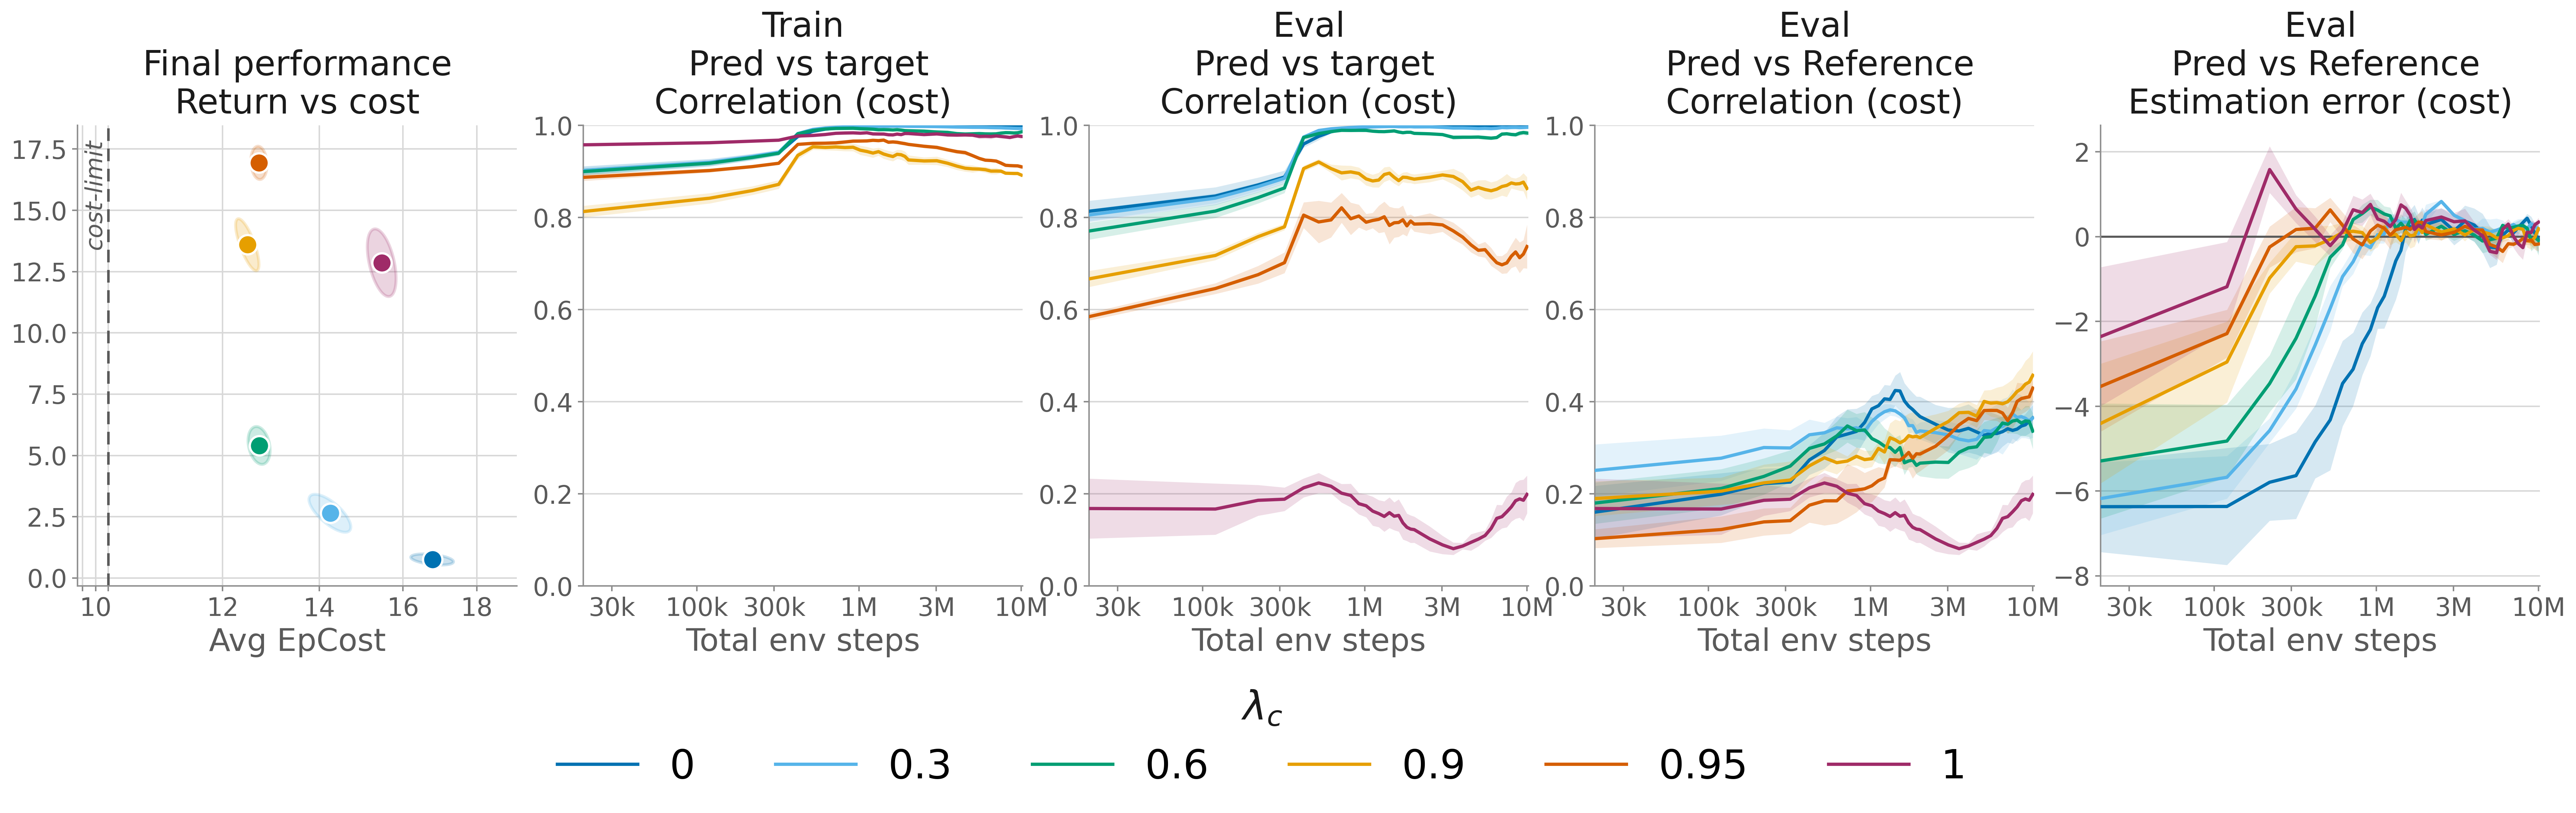

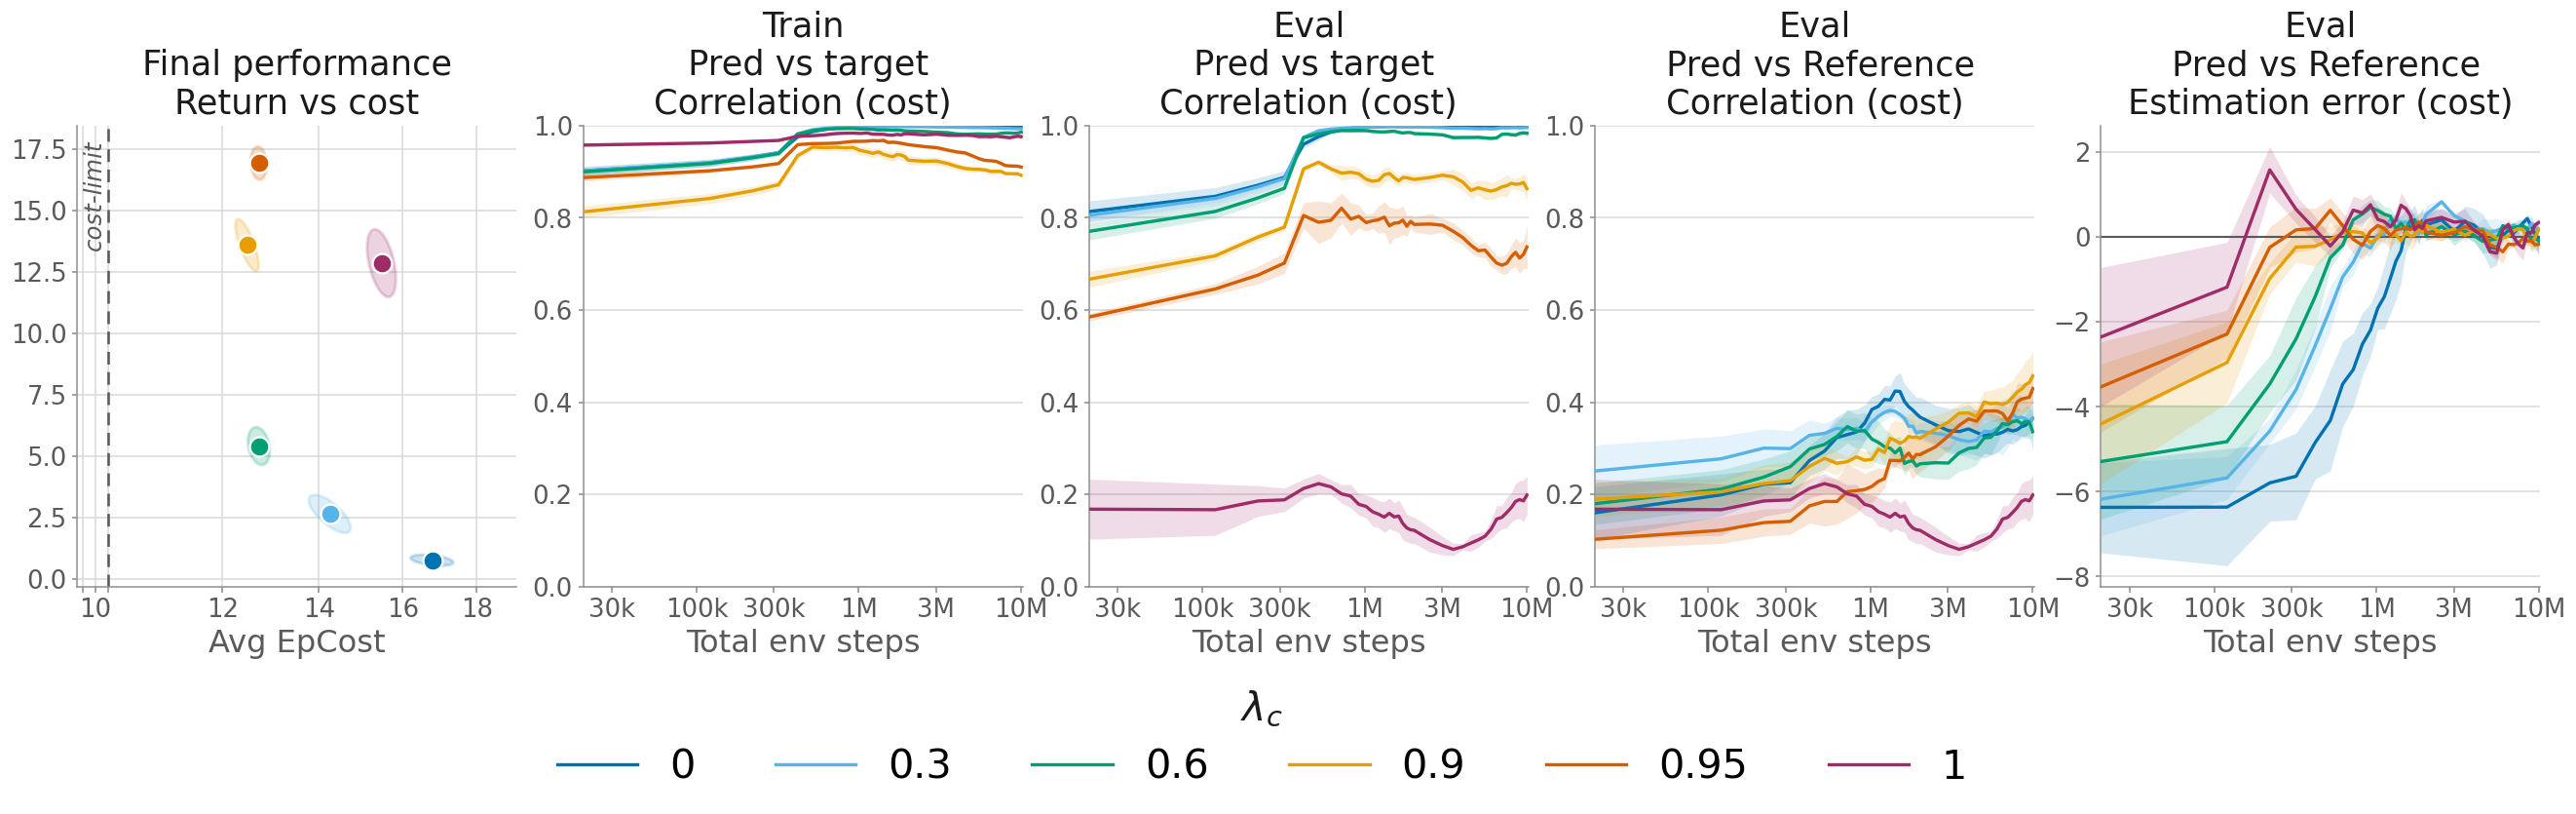

In [15]:
FIG = {
    "perf_xlim": None, "perf_ylim": None,   # None -> from the data
    "perf_xpad": 1.05,                      # margin each side of column 1's x range
    "corr_ylim": (0.0, 1.0),                # columns 2-4 share a correlation scale
    "err_ylim": None,
    "show_seeds": False,                     # per-seed dots behind the ellipses
    # Running mean, in eval checkpoints (37 per run).  wandb's history() returns only
    # rows where every requested key is present, so all five columns share that grid.
    "smooth_corr": 7,                       # columns 2-4
    "smooth_err": 3,                        # column 5
    "legend_in": 1.15,
    "title_in": 1.20,
    "legend_ncol": 6,
    "share_corr": True,                     # put columns 2-4 on one y scale
    "share_rows": True,                     # and one scale down each column
}


def smooth(M, w):
    """Running mean along the last axis, edge-normalised."""
    if w <= 1:
        return M
    k = np.ones(w)
    num = np.apply_along_axis(lambda v: np.convolve(v, k, "same"), -1, M)
    return num / np.convolve(np.ones(M.shape[-1]), k, "same")


def seed_curves(runs, hist, col):
    """(steps, per-seed matrix) for one history column, NaNs dropped first.

    The PooledMC columns are logged only at eval epochs, so a run's column is mostly NaN;
    dropping those rows before aligning keeps the curve intact, where carrying them through
    any windowed operation would erase it.
    """
    ids = set(runs.run_id)
    h = hist[hist.run_id.isin(ids)].dropna(subset=[col, "TotalEnvSteps"])
    per = [g.sort_values("TotalEnvSteps") for _, g in h.groupby("run_id")]
    per = [g for g in per if len(g)]
    if not per:
        return np.array([]), np.zeros((0, 0))
    steps = np.array(sorted(set.intersection(*[set(g.TotalEnvSteps) for g in per])))
    M = np.stack([np.interp(steps, g.TotalEnvSteps, g[col]) for g in per])
    return steps, M


def figure_lambda(series=None, title=None, rows=None):
    """The 5-column panel: one row, or one per entry of `rows`.

    `series` is a list of {label, color, runs, hist}: `runs` the per-seed summary rows behind
    one curve, `hist` the frame its history lives in.  The default is this sweep's own lam_c
    values, but a series may come from another sweep entirely.

    `rows` is a list of {series, label} and takes precedence: the same five columns are drawn
    once per entry, with the label down the left.  That is how a sweep varying something
    beyond lam_c -- the advantage estimator, say -- shows it as a row rather than dissolving
    it into the nuisance grid searched inside each lam_c.
    """
    if rows is None:
        if series is None:
            series = [dict(label=f"{lam:g}", color=LAM_COLOR[lam], runs=SEL[lam], hist=ts)
                      for lam in LAMS]
        rows = [dict(series=series, label=None)]
    rows = list(rows)
    labelled = any(r.get("label") for r in rows)
    fig, axes = make_axes(5, nrows=len(rows), legend_in=FIG["legend_in"],
                          title_in=FIG["title_in"], rowlab=labelled)
    axes = np.atleast_2d(axes)          # make_axes flattens the single-row case
    L, ink = STYLE["line"], STYLE["ink"]
    train_key = f"Value/Train/{TRAIN_STAGE}/CostCriticCorr"
    sc, se = FIG["smooth_corr"], FIG["smooth_err"]

    for r_i, row in enumerate(rows):
        ax, series = axes[r_i], row["series"]
        last = r_i == len(rows) - 1

        # --- 1. final performance: one s.e. ellipse per lambda_c ----------------------
        for s in series:
            d, c = s["runs"], s["color"]
            x, y = d.avg_ep_cost.to_numpy(), d.EpRet.to_numpy()
            if FIG["show_seeds"]:
                ax[0].scatter(x, y, s=L["seed_marker"] ** 2, color=c, alpha=L["seed_alpha"],
                              edgecolors="none", zorder=4)
            sem_ellipse(ax[0], x, y, c)
            ax[0].scatter(x.mean(), y.mean(), s=L["mean_marker"] ** 2, color=c,
                          edgecolor="white", linewidth=1.5, zorder=5)
        ax[0].axvline(COST_LIMIT, color=ink["rule"], lw=L["rule_width"], ls=L["rule_dash"],
                      zorder=2)
        ax[0].annotate(TEXT["cost_limit"], xy=(COST_LIMIT, 0.97),
                       xycoords=ax[0].get_xaxis_transform(), xytext=(-9, 0),
                       textcoords="offset points", rotation=90, ha="center", va="top",
                       fontsize=STYLE["font"]["note"], style="italic", color=ink["label"])
        # Episode cost spans well under a decade, so the default decade locator would label
        # a single tick; step within the decade instead and let thin_tick_labels prune.
        ax[0].set_xscale("log")
        ax[0].xaxis.set_major_locator(mticker.LogLocator(base=10,
                                                         subs=np.arange(1.0, 10.0, 0.2)))
        ax[0].xaxis.set_major_formatter(mticker.ScalarFormatter())
        ax[0].xaxis.set_minor_locator(mticker.NullLocator())
        # keep the limit rule and its label off the spine
        xs = np.concatenate([s["runs"].avg_ep_cost.to_numpy() for s in series])
        pad = FIG["perf_xpad"]
        ax[0].set_xlim(min(xs.min(), COST_LIMIT) / pad, xs.max() * pad)
        ax[0].set_xlabel(TEXT["perf_x"])
        ax[0].grid(True, axis="both", color=ink["grid"], lw=L["grid"])
        if FIG["perf_xlim"]:
            ax[0].set_xlim(*FIG["perf_xlim"])
        if FIG["perf_ylim"]:
            ax[0].set_ylim(*FIG["perf_ylim"])

        # --- 2-5. the cost-critic diagnostics, against env steps ----------------------
        panels = [(ax[1], train_key, sc, 1),
                  (ax[2], "PooledMC/Correlation_pred_target_c", sc, 1),
                  (ax[3], "PooledMC/Correlation_c", sc, 1),
                  (ax[4], "PooledMC/EstimationError_c", se, -1)]  # logged true-pred; negate
        for a, key, w, sign in panels:
            for s in series:
                steps, M = seed_curves(s["runs"], s["hist"], key)
                if not len(steps):
                    continue
                band(a, steps, smooth(sign * M, w), s["color"])
            log_steps(a, X_FIRST, X_LAST)
        for a in ax[1:4]:
            if FIG["corr_ylim"]:
                a.set_ylim(*FIG["corr_ylim"])
        ax[4].axhline(0, color=ink["rule"], lw=1.4, zorder=2)
        if FIG["err_ylim"]:
            ax[4].set_ylim(*FIG["err_ylim"])

        if FIG["share_corr"]:
            lims = [a.get_ylim() for a in ax[1:4]]
            lo, hi = min(l for l, _ in lims), max(h for _, h in lims)
            for a in ax[1:4]:
                a.set_ylim(lo, hi)

        if r_i == 0:
            for a, t in zip(ax, TEXT["titles"]):
                a.set_title(t)
        if not last:                    # only the bottom row carries the x labels
            for a in ax:
                a.set_xlabel("")
        if row.get("label"):
            row_label(fig, ax[0], row["label"])
        for a in ax:
            thin_tick_labels(fig, a)

    if len(rows) > 1 and FIG["share_rows"]:
        for j in range(1, 5):           # one scale down each diagnostic column
            lims = [axes[r][j].get_ylim() for r in range(len(rows))]
            lo, hi = min(l for l, _ in lims), max(h for _, h in lims)
            for r in range(len(rows)):
                axes[r][j].set_ylim(lo, hi)

    # every row draws the same lam_c set, so one legend taken from the first suffices
    legend_below(fig, [(line_key(s["color"]), s["label"]) for s in rows[0]["series"]],
                 ncol=FIG["legend_ncol"], title=TEXT["legend_title"])
    # suptitle(fig, title or TEXT["suptitle"])
    return fig


save(figure_lambda(), "fig3_lambda_c")
show("fig3_lambda_c")

## 5.1 $\lambda_c = 1$ taken from the `gae-rtg` target

In this sweep $\lambda_c = 1$ is the $\lambda \to 1$ limit of the same TD($\lambda$)
recursion. Sweep **`7jh54wrh`** — *(A) CPO (different targets) (PointGoal1)*, same algorithm,
env and 10.24M-step budget — instead varies `cost-adv-estimation-method` directly, and its
`gae-rtg` arm builds the cost target from the reward-to-go: a Monte-Carlo target by
construction rather than as a limit.

This cell redraws the figure with that arm standing in for $\lambda_c = 1$; the other five
curves are untouched. It keeps the $\lambda_c = 1$ colour, so the two figures can be read
against each other.

`7jh54wrh` has no `lam-c` axis (it is fixed at 0.95, which `gae-rtg` overrides anyway), so
the nuisance grid searched there is `adv` x `update_iters` x `critic_lr`. `RTG["adv"]` pins
the *reward* advantage to `gae` to match `tuukeqwe`, which fixes it that way — otherwise the
swapped-in series would differ in two things at once. Set it to `None` to search both.

gae-rtg: adv=gae iters=2 lr=0.0003  EpRet  14.00  avg ep cost  13.59  ratio 1.033  5 seeds
saved: fig3_lambda_c_gae_rtg png/pdf


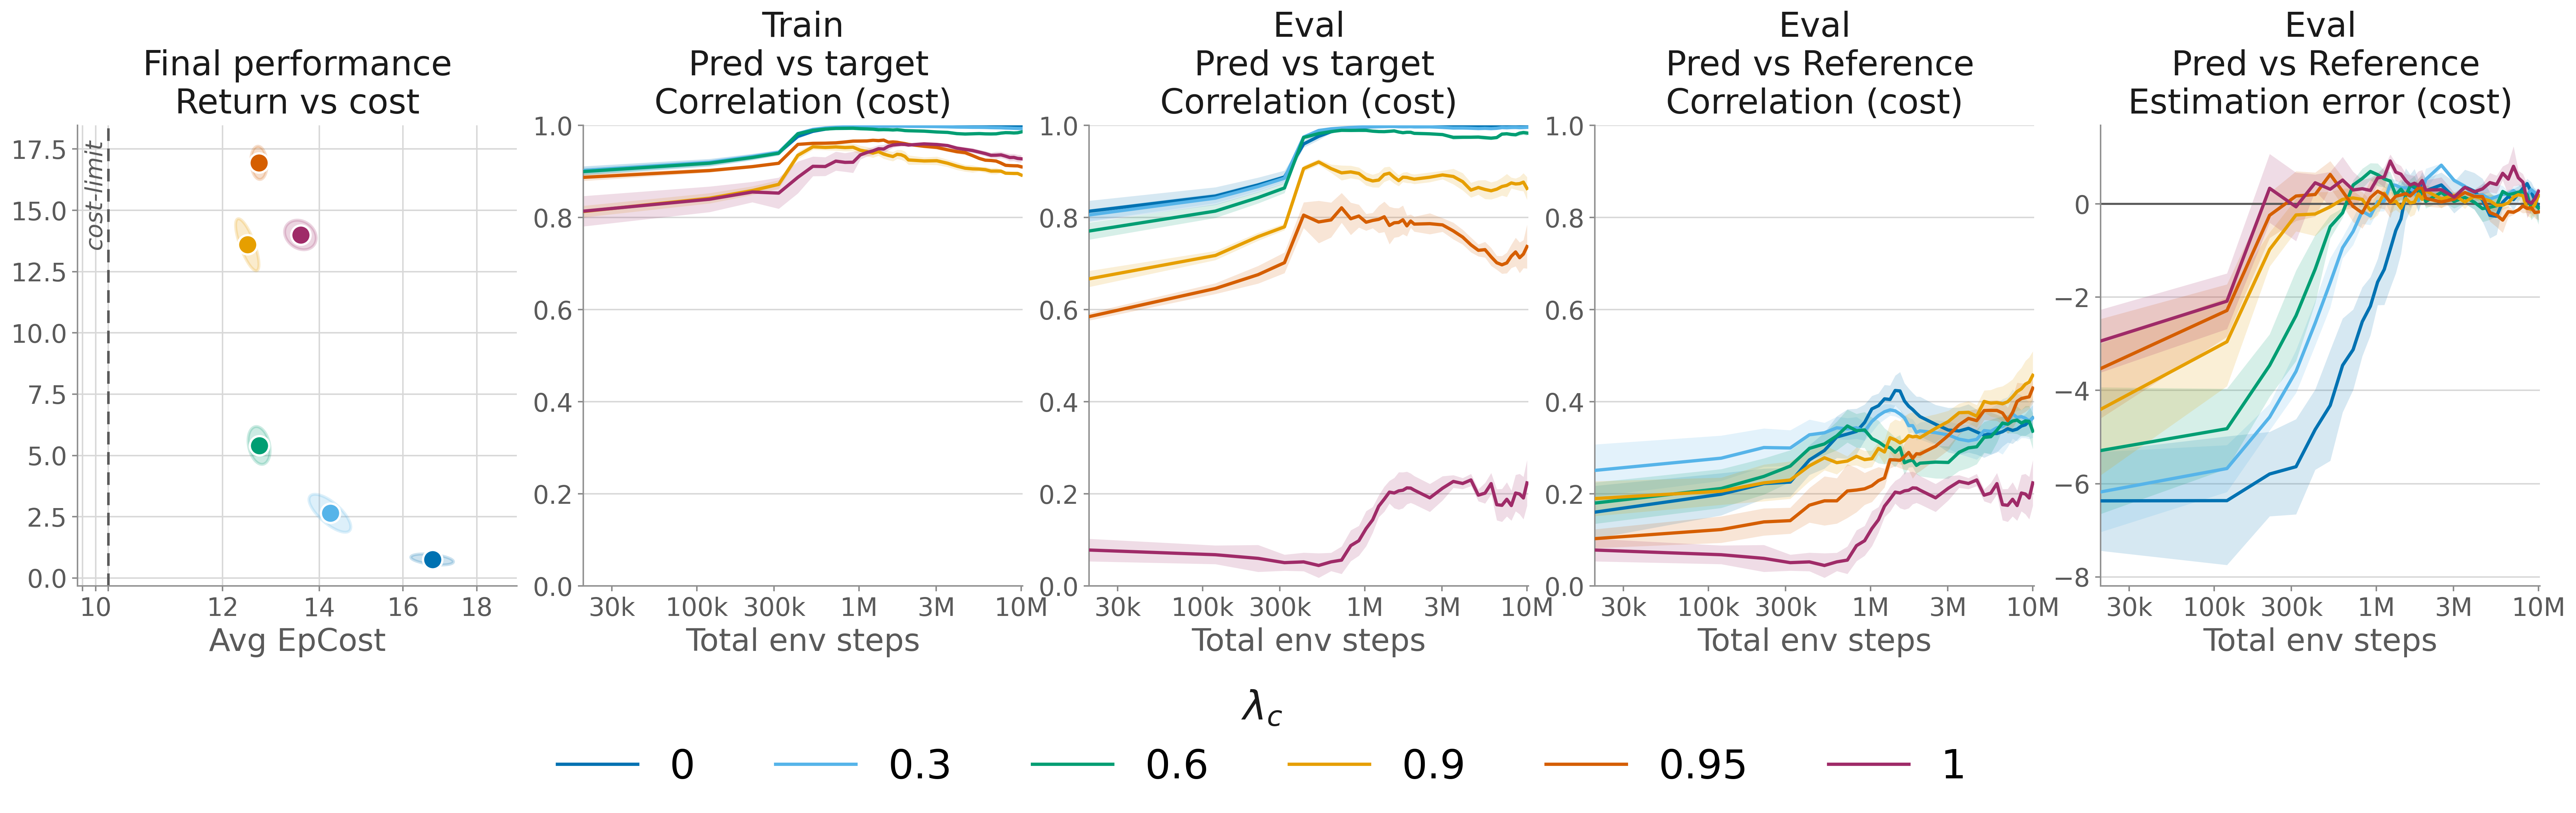

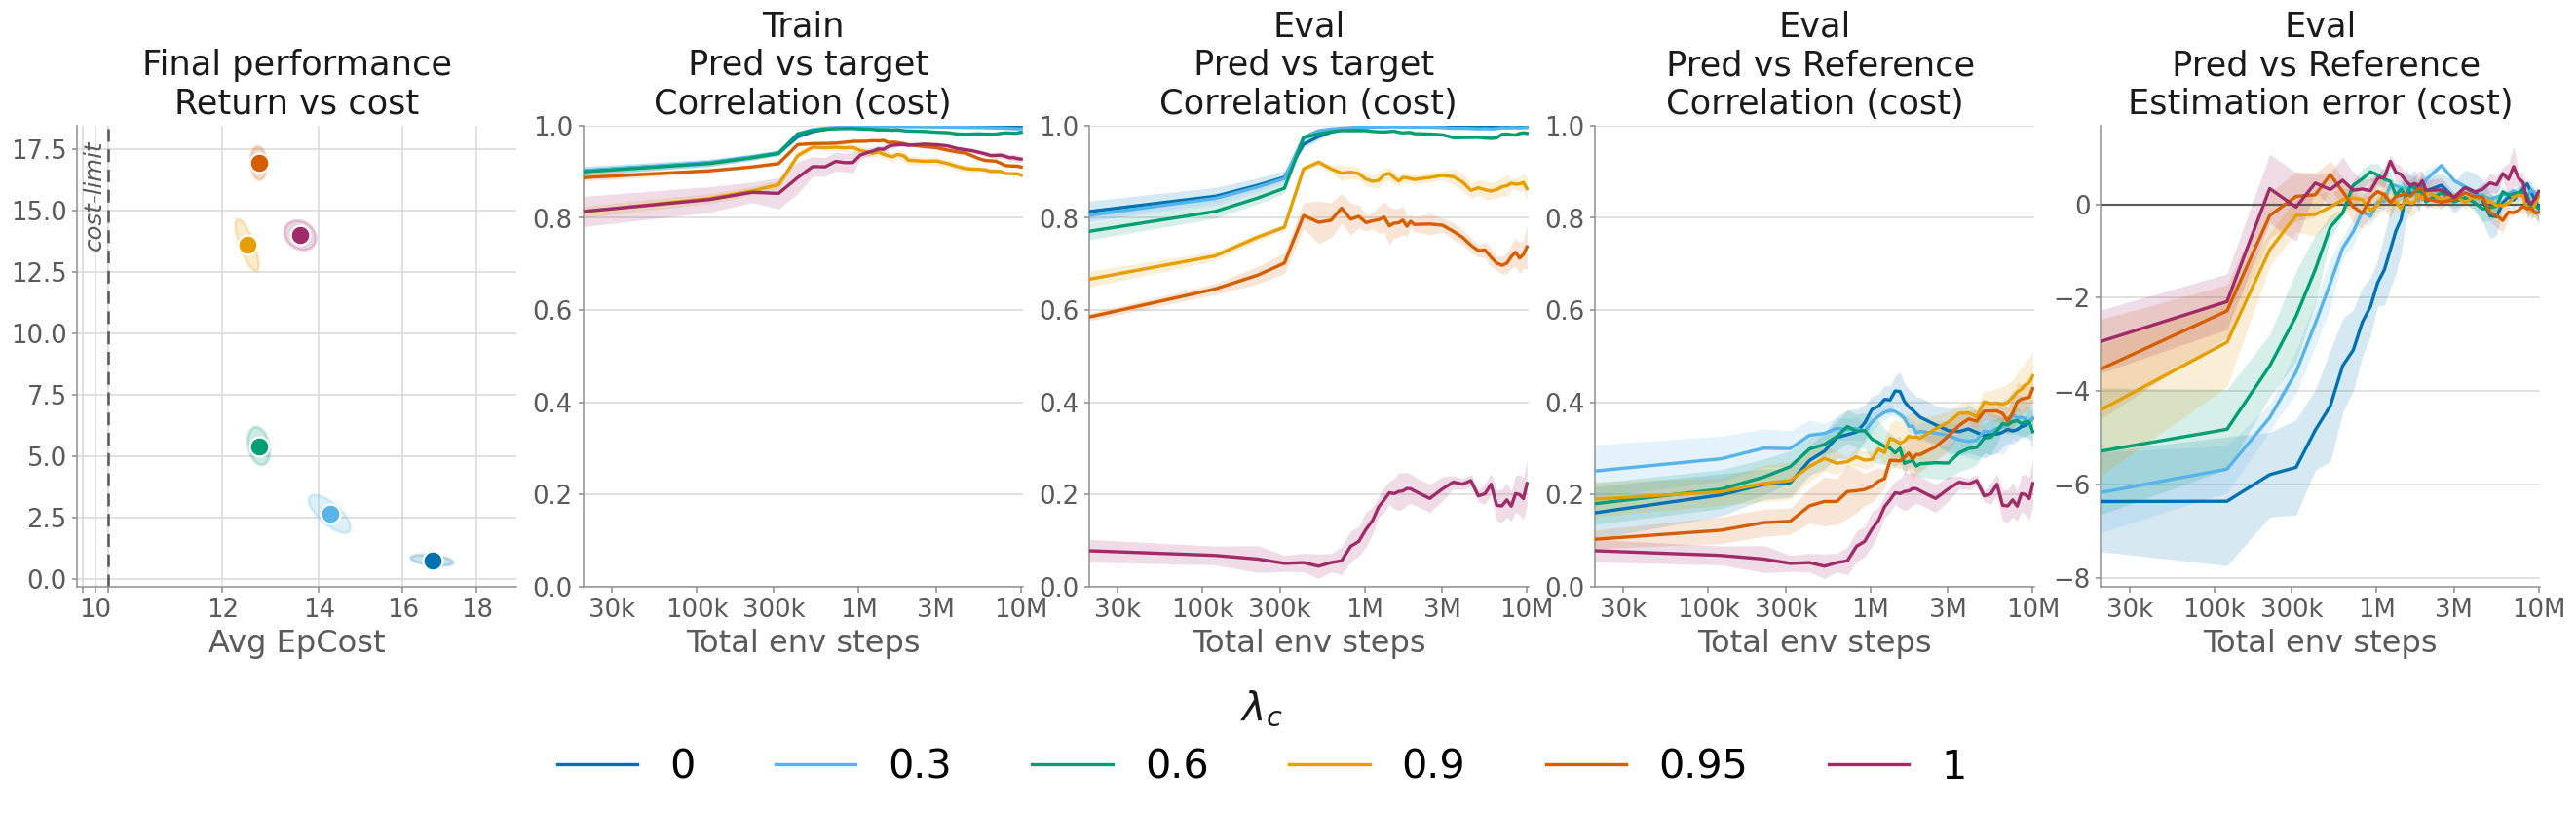

In [16]:
RTG = {
    "sweep": "liam-paull/calibration_rl/7jh54wrh",
    "cost_adv": "gae-rtg",
    "adv": "gae",          # match tuukeqwe's reward advantage; None searches both
    "replace": 1.0,        # the lam_c this series stands in for
    "label": "1",
}

RTG_DIR = REPO / "figs" / f"sweep_{RTG['sweep'].rsplit('/', 1)[1]}"
RTG_DIR.mkdir(parents=True, exist_ok=True)
RTG_RAW, RTG_TS = RTG_DIR / "raw_runs.csv", RTG_DIR / "all_runs_timeseries.csv"


def rtg_best(raw2):
    """Best (adv, update_iters, critic_lr) among that sweep's gae-rtg runs.

    Scored by SELECT["criterion"], exactly as each lam_c is scored above, so the swapped-in
    series is chosen on the same rule as the ones it sits beside.
    """
    d = per_run_scores(raw2)
    d = d[d.cost_adv == RTG["cost_adv"]]
    if RTG["adv"] is not None:
        d = d[d.adv == RTG["adv"]]
    if d.empty:
        raise RuntimeError(f"no {RTG['cost_adv']} runs matched in {RTG['sweep']}")
    g = (d.groupby(["adv"] + CFG_KEYS)
         .agg(ratio=("ratio", "mean"), EpRet=("EpRet", "mean"),
              avg_ep_cost=("avg_ep_cost", "mean"), n_seeds=("seed", "size"))
         .reset_index())
    crit = SELECT["criterion"]
    row = g.loc[g[crit].idxmin() if CRITERIA[crit]["mode"] == "min" else g[crit].idxmax()]
    m = (d.adv == row.adv).to_numpy()
    for k in CFG_KEYS:
        m &= np.isclose(d[k].astype(float), float(row[k]))
    return row, d[m].sort_values("seed")


raw_rtg = pd.read_csv(RTG_RAW) if RTG_RAW.exists() else fetch_summary(RTG["sweep"])
if not RTG_RAW.exists():
    save_csv(raw_rtg, RTG_RAW)
raw_rtg = to_numeric(raw_rtg, ["update_iters", "critic_lr", "seed",
                               "EpRet", "EpLen", "TotalCost", "TotalEnvSteps"])

rtg_row, rtg_runs = rtg_best(raw_rtg)
print(f"{RTG['cost_adv']}: adv={rtg_row.adv} iters={int(rtg_row.update_iters)} "
      f"lr={rtg_row.critic_lr:g}  EpRet {rtg_row.EpRet:6.2f}  "
      f"avg ep cost {rtg_row.avg_ep_cost:6.2f}  ratio {rtg_row.ratio:.3f}  "
      f"{int(rtg_row.n_seeds)} seeds")

rtg_ids = list(rtg_runs.run_id)
if RTG_TS.exists():
    ts_rtg = pd.read_csv(RTG_TS)
    missing = sorted(set(rtg_ids) - set(ts_rtg.run_id))
    if missing:
        print(f"cache is missing {len(missing)} selected runs; fetching them")
        ts_rtg = pd.concat([ts_rtg, fetch_history(missing)], ignore_index=True)
        save_csv(ts_rtg, RTG_TS)
else:
    print(f"fetching history for {len(rtg_ids)} runs")
    ts_rtg = fetch_history(rtg_ids)
    save_csv(ts_rtg, RTG_TS)
ts_rtg = to_numeric(ts_rtg, HISTORY_KEYS)

# the same series as above, with lam_c = 1 swapped for the gae-rtg config
rtg_series = [dict(label=f"{lam:g}", color=LAM_COLOR[lam], runs=SEL[lam], hist=ts)
              for lam in LAMS if lam != RTG["replace"]]
rtg_series.append(dict(label=RTG["label"], color=LAM_COLOR[RTG["replace"]],
                       runs=rtg_runs, hist=ts_rtg))

save(figure_lambda(rtg_series, TEXT["suptitle_rtg"]), "fig3_lambda_c_gae_rtg")
show("fig3_lambda_c_gae_rtg")

## 5.2 The same figure for sweep `dp4js0yi`

A second $\lambda_c$ sweep on the same algorithm, environment and step budget, with the same
six values of `lam-c`. Two things differ:

| | `tuukeqwe` (above) | `dp4js0yi` |
|---|---|---|
| `adv-estimation-method` | fixed to `gae` | **varies**: `gae`, `plain` |
| `cost-adv-estimation-method` | `gae` | `td_zero` |
| `cost-value-target-method` | (default) | `td_lambda` |
| runs | 120 | 240 |

The advantage estimator is shown as a **row** rather than folded into the grid searched inside
each $\lambda_c$: dissolving it there would let one $\lambda_c$ win on `gae` and its neighbour
on `plain`, and the curve would mix the two. Held as a row, every $\lambda_c$ in a row shares
an estimator and the rows are directly comparable — which is the whole question this sweep
asks. Inside a row the nuisance grid is `update_iters` x `critic_lr`, exactly as above.

Columns 2–5 share a y scale down the figure, so the two rows can be read against each other.
The cache lives under `figs/sweep_dp4js0yi/`.

In [ ]:
ALT = {
    "sweep": "liam-paull/calibration_rl/dp4js0yi",
    "row_key": "adv",          # one row per value of this column
    "rows": None,              # None -> every value present, sorted
    "keys": CFG_KEYS,          # nuisance grid searched inside each (row, lam_c)
    "row_label": "adv = {v}",
}

ALT_ID = ALT["sweep"].rsplit("/", 1)[1]
ALT_DIR = REPO / "figs" / f"sweep_{ALT_ID}"
ALT_DIR.mkdir(parents=True, exist_ok=True)
ALT_RAW, ALT_TS = ALT_DIR / "raw_runs.csv", ALT_DIR / "all_runs_timeseries.csv"


def alt_summary():
    """The alternate sweep's summary, cached."""
    raw = pd.read_csv(ALT_RAW) if ALT_RAW.exists() else fetch_summary(ALT["sweep"])
    if not ALT_RAW.exists():
        save_csv(raw, ALT_RAW)
    raw = to_numeric(raw, ["lam_c", "update_iters", "critic_lr", "seed",
                           "EpRet", "EpLen", "TotalCost", "TotalEnvSteps"])
    # A cache written before a config column was recorded reads back all-NaN, which
    # would otherwise surface as an empty figure or "No objects to concatenate".
    blank = [k for k in [LAM_KEY, ALT["row_key"], *ALT["keys"]]
             if k in raw.columns and raw[k].isna().all()]
    if blank:
        raise RuntimeError(
            f"{ALT_RAW.name} has no values for {blank}: it was cached without those "
            "config columns. Delete it (and all_runs_timeseries.csv beside it) to "
            "refetch.")
    missing = [k for k in [LAM_KEY, ALT["row_key"], *ALT["keys"]]
               if k not in raw.columns]
    if missing:
        raise KeyError(f"{missing} not recorded for this sweep; columns are "
                       f"{list(raw.columns)}")
    return raw


def alt_rows(raw):
    """Per row value: the winning config for each lam_c, and the runs behind it."""
    vals = ALT["rows"] or sorted(raw[ALT["row_key"]].dropna().astype(str).unique())
    crit = CRITERIA[SELECT["criterion"]]
    print(f"{ALT_ID}: {len(raw)} runs | best by {crit['label']} ({crit['mode']}), "
          f"grid {ALT['keys']} inside each {ALT['row_key']}")
    out = []
    for v in vals:
        sub = raw[raw[ALT["row_key"]].astype(str) == str(v)].copy()
        if sub.empty:
            raise RuntimeError(f"{ALT['row_key']}={v!r} matched no runs; present: "
                               f"{sorted(raw[ALT['row_key']].dropna().astype(str).unique())}")
        best = best_per_lam(sub, SELECT["criterion"], ALT["keys"])
        lams = list(best.index)
        sel = {lam: runs_of(sub, lam, best, ALT["keys"]) for lam in lams}
        print(f"  {ALT['row_key']}={v}")
        for lam in lams:
            b = best.loc[lam]
            print(f"    lam_c={lam:<5g} " + " ".join(f"{k}={b[k]}" for k in ALT["keys"])
                  + f"  EpRet {b.EpRet:6.2f}  avg ep cost {b.avg_ep_cost:6.2f}  "
                    f"ratio {b.ratio:.3f}  {int(b.n_seeds)} seeds")
        out.append(dict(value=v, lams=lams, sel=sel))
    return out


def alt_history(rowdefs):
    """History for the selected runs only -- never the whole sweep."""
    ids = [rid for rd in rowdefs for lam in rd["lams"] for rid in rd["sel"][lam].run_id]
    if ALT_TS.exists():
        h = pd.read_csv(ALT_TS)
        missing = sorted(set(ids) - set(h.run_id))
        if missing:
            print(f"  cache is missing {len(missing)} selected runs; fetching them")
            h = pd.concat([h, fetch_history(missing)], ignore_index=True)
            save_csv(h, ALT_TS)
    else:
        print(f"  fetching history for {len(ids)} runs")
        h = fetch_history(ids)
        save_csv(h, ALT_TS)
    return to_numeric(h, HISTORY_KEYS)


ALT_ROWDEFS = alt_rows(alt_summary())
ALT_TS_DF = alt_history(ALT_ROWDEFS)

alt_fig_rows = []
for rd in ALT_ROWDEFS:
    if len(rd["lams"]) > len(STYLE["lam"]):
        raise RuntimeError(f"{len(rd['lams'])} lambda values but "
                           f"{len(STYLE['lam'])} ramp steps")
    alt_fig_rows.append(dict(
        label=ALT["row_label"].format(v=rd["value"]),
        series=[dict(label=f"{lam:g}", color=STYLE["lam"][i], runs=rd["sel"][lam],
                     hist=ALT_TS_DF)
                for i, lam in enumerate(rd["lams"])]))

save(figure_lambda(rows=alt_fig_rows), f"fig3_lambda_c_{ALT_ID}")
show(f"fig3_lambda_c_{ALT_ID}")

## 5.3 Before vs after the update, per $\lambda_c$

One subplot per $\lambda_c$, each showing the training-batch correlation
Corr($\hat V_c$, TD($\lambda$) target) at **both** points in the epoch:

- **BeforeUpdate** — the critic as it entered the epoch, scored on the incoming batch
- **AfterUpdate** — the same critic once that epoch's update has fitted it to that batch

The gap between them is one update step's worth of fitting, and it is worth seeing on its own
because it decides which of the two belongs beside the eval columns. `_run_eval_studies` is
called **before** `_update()` in the training loop, so the eval probes are scored with the
*entering* weights — the same ones `BeforeUpdate` measures. `AfterUpdate` is a fit to data the
critic has just trained on, and is not comparable with a held-out evaluation.

Colour is the stage; the shaded wedge between the two means is the gap itself.

In [ ]:
STAGES = {
    "keys": {"BeforeUpdate": "Value/Train/BeforeUpdate/CostCriticCorr",
             "AfterUpdate": "Value/Train/AfterUpdate/CostCriticCorr"},
    "color": {"BeforeUpdate": "#0072B2", "AfterUpdate": "#D55E00"},
    "ncols": 6,                 # 6 -> one row; 3 -> a 2x3 block
    "smooth": 7,
    "ylim": (0.0, 1.02),
    "fill_gap": True,
    "legend_in": 1.15,
    "title_in": 0.60,
    "ylabel": "Corr(pred, target), train batch",
}


def figure_stages(lams=None, sel=None, hist=None, title=None):
    """One panel per lam_c, each comparing the two points in the update cycle."""
    lams = list(lams if lams is not None else LAMS)
    sel = sel if sel is not None else SEL
    hist = hist if hist is not None else ts
    ncols = min(STAGES["ncols"], len(lams))
    nrows = -(-len(lams) // ncols)
    fig, axes = make_axes(ncols, nrows=nrows, legend_in=STAGES["legend_in"],
                          title_in=STAGES["title_in"])
    axes = np.atleast_2d(axes)
    flat = [axes[r][c] for r in range(nrows) for c in range(ncols)]
    ink = STYLE["ink"]

    gaps = {}
    for i, lam in enumerate(lams):
        a = flat[i]
        means = {}
        for stage, key in STAGES["keys"].items():
            steps, M = seed_curves(sel[lam], hist, key)
            if not len(steps):
                continue
            means[stage] = (steps, band(a, steps, smooth(M, STAGES["smooth"]),
                                        STAGES["color"][stage]))
        if STAGES["fill_gap"] and len(means) == 2:
            (s0, m0), (s1, m1) = means["BeforeUpdate"], means["AfterUpdate"]
            if len(s0) == len(s1) and np.allclose(s0, s1):
                a.fill_between(s0, m0, m1, color=ink["grid"], alpha=0.55, lw=0, zorder=1)
                gaps[lam] = float(np.nanmean(m1 - m0))
        a.set_title(rf"$\lambda_c$ = {lam:g}")
        log_steps(a, X_FIRST, X_LAST)
        if STAGES["ylim"]:
            a.set_ylim(*STAGES["ylim"])
        thin_tick_labels(fig, a)
    for a in flat[len(lams):]:          # trailing panels of a ragged grid
        a.set_visible(False)
    axes[0][0].set_ylabel(STAGES["ylabel"])

    legend_below(fig, [(line_key(STAGES["color"][s]), s) for s in STAGES["keys"]], ncol=2)
    if title:
        suptitle(fig, title)
    if gaps:
        print("mean AfterUpdate - BeforeUpdate, over training:")
        for lam, g in gaps.items():
            print(f"  lam_c={lam:<5g} {g:+.4f}")
    return fig


save(figure_stages(), "fig3_train_stages")
show("fig3_train_stages")

## 6. Which config each $\lambda_c$ picked

The selection is not always stable across criteria; this makes the choice explicit.

In [8]:
rows = []
for crit in CRITERIA:
    b = best_per_lam(raw, crit)
    for lam in b.index:
        r = b.loc[lam]
        rows.append(dict(criterion=crit, lam_c=lam, update_iters=int(r.update_iters),
                         critic_lr=r.critic_lr, EpRet=round(float(r.EpRet), 2),
                         avg_ep_cost=round(float(r.avg_ep_cost), 2),
                         ratio=round(float(r.ratio), 3), n_seeds=int(r.n_seeds)))
table = pd.DataFrame(rows)
try:
    display(table)
except NameError:
    print(table.to_string(index=False))

,criterion,lam_c,update_iters,critic_lr,EpRet,avg_ep_cost,ratio,n_seeds
0,ratio,0.00,5,0.0001,0.75,16.77,0.046,5
1,ratio,0.30,2,0.0003,2.64,14.25,0.191,5
2,ratio,0.60,5,0.0001,5.41,12.72,0.427,5
3,ratio,0.90,2,0.0001,13.60,12.48,1.095,5
4,ratio,0.95,2,0.0003,16.94,12.72,1.333,5
5,ratio,1.00,5,0.0003,12.86,15.47,0.837,5
6,EpRet,0.00,5,0.0001,0.75,16.77,0.046,5
7,EpRet,0.30,2,0.0003,2.64,14.25,0.191,5
8,EpRet,0.60,5,0.0001,5.41,12.72,0.427,5
9,EpRet,0.90,2,0.0001,13.60,12.48,1.095,5


## 7. Output

In [9]:
for p in sorted(FIG_DIR.iterdir()):
    print(f"{p.stat().st_size / 1e3:8.1f} kB  {p.name}")

    59.3 kB  fig3_lambda_c.pdf
  1321.1 kB  fig3_lambda_c.png
